# TRIDENT for CGM-oriented experiments

In the last tutorial, we already saw how to deal with the basics of a TNG dataset, and also some basic functionalities of TRIDENT.
Now, we will aim to use TRIDENT to create mock spectra by piercing our already downloaded subhalo. 

In particular:
- We will produce Mg II $\lambda\lambda 2796, 2803$, C IV $\lambda\lambda 1548, 1551$ absorption doublets. 
- Explore how to the effect of spectral resolution and pixel dispersion. 
- Finalize with an experiment of determining the kinematics of the gas from an edge-on view of the galaxy. 

## TRIDENT in a nutshell

TRIDENT works in a three-step fashion. First, for a given datasset it estimates the ions component of a given desired species not tracked by the dataset. For example, TNG tracks both HI and HII, but it does not track any ions for metals, and therefore their contents needs to be estimated before hand. To do this estimation, TRIDENT assumes ionization equilibrium to estimate the ionization fraction ($f_{X_i}$) of a given ion. Under those circumstances, $f_{X_i}$ is a function of density, temperature and the background radiation field (which depends mostly on redshift). A visual summary is shown in the figure. 

<div style="text-align: center;">
    <img src="images/trident_summary.jpg" width="300"/>
</div>

After succesfully estimating the ions component of a given dataset, the usser can trace a ray that pierces the dataset to produce. Each produce ray will stored the neccesary information to then produce the corresponding absorption spectrum, which corresponds to the temperature, ion number density, and projected velocity along the ray. 

Finally, for each pierced resolution element of the simulation, a Voigt profile is deposited assuming a non-turbulent regime (i.e., the doppler parameter only considers thermal broadenning). 

After the spectrum is created, it can be further post-processed to obtain a more realistic outcome comparable to real observations.

In [1]:
# Importing all essentials 
import numpy as np
import matplotlib.pyplot as plt 
import plotting_setup # comment this line if running local
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import coordinates as coords
import os

import illustris_python as ill 
import trident
import yt
import yt.units
from yt.units import kpc


C:\ProgramData\Anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
def fit_delta_crit(x):
    # Extracted from Bryan 1998 (fit with Omega_R = 0)
    return 18*np.pi**2 + 82*x - 39*(x**2)

def virial_radius(M, z):
    # Mass has to be given in units of solar masses
    cosmo = FlatLambdaCDM(H0 = 67.74, Om0=0.3089, Ob0=0.0486)
    density = fit_delta_crit(cosmo.Om(z) - 1) * cosmo.critical_density(z)
    
    # density = 200 * cosmo.critical_density(z)  use this to use typical TNG definition of the virial radius

    density = density.to(u.M_sun/u.kpc**3)
    r_cube = (3/(4*np.pi*density)) * (M*u.M_sun)

    return r_cube**(1/3)

**Note:** always check the TRIDENT database of absorption lines. This is typically found in the installation folder. This database includes all the neccesary information to produce a Voigt profile for a given species, like the oscillator strength, the damping constant and the rest-frame wavelenght. 

In [3]:
# Check TRIDENT path
trident.__path__

['C:\\ProgramData\\Anaconda3\\lib\\site-packages\\trident']

In [4]:
# Extracting relevant information from the group catalogs
basePath = 'D:/TNG-and-TRIDENT-for-CGM-oriented-science'

fields = ['SubhaloSFRinHalfRad', 'SubhaloMassInHalfRadType', 'SubhaloSFR', 'SubhaloPos', 
          'SubhaloVel' , 'SubhaloGrNr' , 'SubhaloMass', 'SubhaloCM'] 

subhalos_catalog = ill.groupcat.loadSubhalos(basePath, 50,fields=fields) 

# We will also add the units accordingly 

center = subhalos_catalog['SubhaloCM'][110863] # we will left this with code units         
velocity_gal = subhalos_catalog['SubhaloVel'][110863] * (yt.units.km / yt.units.s) 
total_mass = subhalos_catalog['SubhaloMass'][110863] * (1e10/0.6774) * yt.units.Msun 

In [5]:
R_vir = virial_radius(total_mass, 1) 

In [6]:
# Now we load our dataset with yt!
ds = yt.load('cutout_10.hdf5') 

# We add the ion fields to our dataset :) 
trident.add_ion_fields(ds, ions = ['Mg II', 'C IV', 'Fe II']) # we only need to add the missing ions (HI is already tracked in TNG)

yt : [INFO     ] 2025-06-24 14:48:52,620 Calculating time from 5.007e-01 to be 1.855e+17 seconds
yt : [INFO     ] 2025-06-24 14:48:52,725 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-24 14:48:52,727 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-24 14:48:52,729 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-06-24 14:48:52,731 Parameters: domain_right_edge         = [35000. 35000. 35000.]
yt : [INFO     ] 2025-06-24 14:48:52,733 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-24 14:48:52,733 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-24 14:48:52,733 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-24 14:48:52,734 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-24 14:48:52,734 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-24 14:48:52,735 Parameters: hubble_constant

Let's create our first ray that will through the center of this galaxy. To do that, we only need to specify a starting and and ending point. We will go throught the center of this galaxy moving 2 times the virial radius in the $\hat{z}$ direction of the coordinates of the simulation. 

In [51]:
center_kpc = center * ds.length_unit.in_units('kpc')

starting_point = [center_kpc[0], center_kpc[1], center_kpc[2] - R_vir.value * kpc]
ending_point = [center_kpc[0], center_kpc[1], center_kpc[2] + R_vir.value * kpc]

# We will define the lines we want to produce 
# TRIDENT nomenclaure is Atom Ionization Rest wavelength (rounded to the closest integer) 
# Also, if you want to generate all lines for a given species, you can just 
lines_list = ['H I','Mg II 2796', 'Mg II 2804', 'Fe II 2344', 'C IV 1548', 'C IV 1551'] 

Since I'll be creating many rays, I'll create some folders to save the rays, and also to save the spectra. 

In [ ]:
%%bash
mkdir rays
mkdir spectra

In [13]:
# Now we create our ray
ray = trident.make_simple_ray(ds,
                              start_position=starting_point,
                              end_position=ending_point,
                              data_filename="rays/ray_DTB.h5",
                              lines=lines_list, line_database='database_tutorial.txt', 
                              fields=[('PartType0', 'H_p1_number_density')])   # I'm additionally asking for the ray to save HII :) 

yt : [INFO     ] 2025-06-24 13:08:13,158 Getting segment at z = 0.9972942257819404: [0.76683243 0.09175672 0.18873075] unitary to [0.76683243 0.09175672 0.20212618] unitary.
yt : [INFO     ] 2025-06-24 13:08:13,160 Getting subsegment: [0.76683243 0.09175672 0.18873075] unitary to [0.76683243 0.09175672 0.20212618] unitary.
yt : [INFO     ] 2025-06-24 13:08:23,639 Saving field data to yt dataset: rays/ray_DTB.h5.
yt : [INFO     ] 2025-06-24 13:08:23,714 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-24 13:08:23,718 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-24 13:08:23,720 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-24 13:08:23,722 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-24 13:08:23,723 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-24 13:08:23,724 Parameters: current_redshift          = 0.997

We can explore the density probed along the ray.

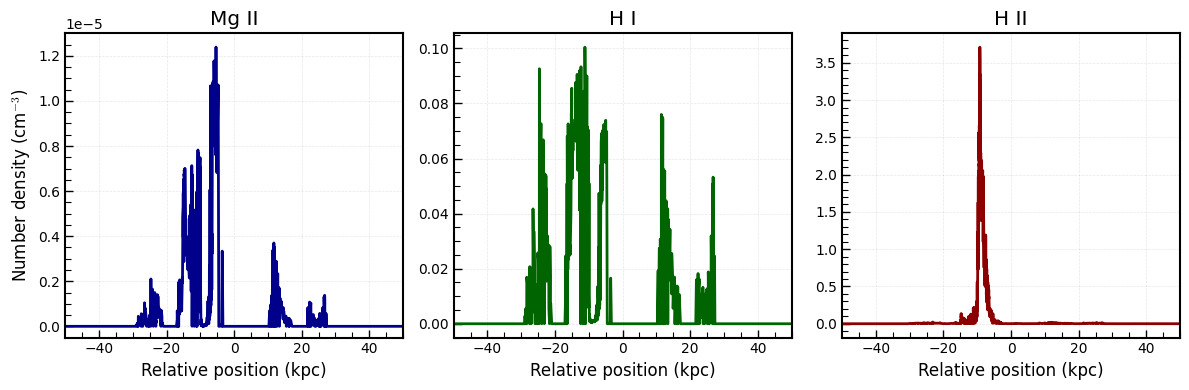

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
relative_position = ray.data[('gas', 'l')].to('kpc') - R_vir.value * kpc

# Panel 1: Mg II number density
axs[0].plot(relative_position, ray.data[('all', 'Mg_p1_number_density')], color='darkblue')
axs[0].set_xlim(-50, 50)
axs[0].set_ylim(-0.5e-6, 1.3e-5)
axs[0].set_xlabel('Relative position (kpc)')
axs[0].set_ylabel(r'Number density (cm$^{-3}$)')
axs[0].set_title(r'Mg II')
axs[0].grid(True, alpha=0.3)

# Panel 2: H I number density
axs[1].plot(relative_position, ray.data[('all', 'H_p0_number_density')], color='darkgreen')
axs[1].set_xlim(-50, 50)
axs[1].set_xlabel('Relative position (kpc)')
axs[1].set_title(r'H I')
axs[1].grid(True, alpha=0.3)

# Panel 3: H II number density
axs[2].plot(relative_position, ray.data[('all', 'H_p1_number_density')], color='darkred')
axs[2].set_xlim(-50, 50)
axs[2].set_xlabel('Relative position (kpc)')
axs[2].set_title(r'H II')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now, we can create our spectrum! 

In [52]:
spectra_path = 'spectra/'
z = ds.current_redshift

ray_name = 'rays/ray_DTB.h5'
name_spectrum = spectra_path + f'spectrum_DTB.txt'
min_lambda = (1+z) * 950 # shortest wavelength will come from Lyman gamma at ~972 A
max_lambda = (1+z) * 2825 # longest wavelength will come from Mg II at ~2800 A
    
sg = trident.SpectrumGenerator(lambda_min=min_lambda, lambda_max=max_lambda,
                                   dlambda=0.01,                                   # The equivalenth of "pixel dispersion" 
                                   line_database='database_tutorial.txt')           # Very important to change it accordingly!
sg.make_spectrum(ray_name, lines=lines_list)
sg.save_spectrum(name_spectrum)

yt : [INFO     ] 2025-06-24 15:56:49,709 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-24 15:56:49,712 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-24 15:56:49,715 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-24 15:56:49,717 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-24 15:56:49,718 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-24 15:56:49,719 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-24 15:56:49,720 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-24 15:56:49,720 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-24 15:56:49,721 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-24 15:56:49,721 Parameters: hubble_constant           = 0.6774
yt : [INFO     ] 2025-06-24 15:56:49,742 Allocating f

Text(0, 0.5, 'Normalized flux = $e^{-\\tau(\\lambda)}$')

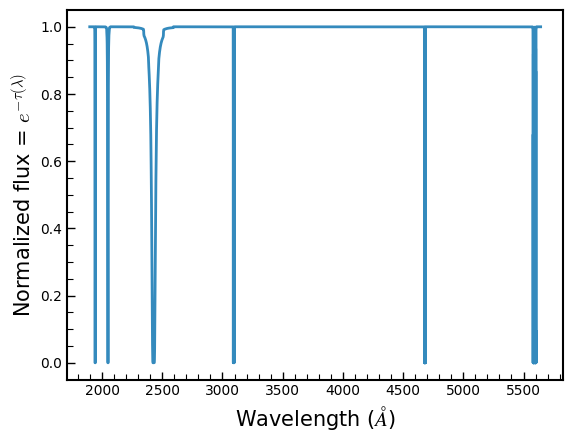

In [53]:
# We load our spectrum, note that the columns are wavelength, optical depth, flux, and flux error

spectrum = np.loadtxt('spectra/spectrum_DTB.txt')

plt.plot(spectrum[:,0], spectrum[:,2])
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)

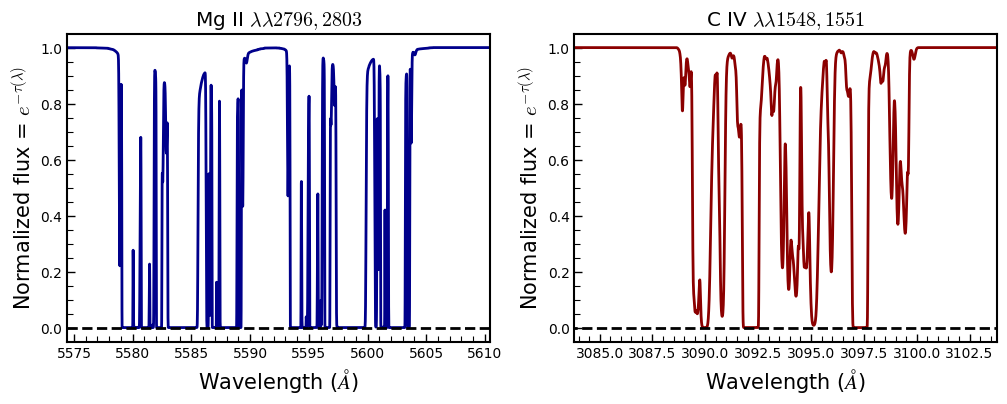

In [54]:
# Let's have a look at Mg II and C IV doublets individual species. 

plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(spectrum[:,0], spectrum[:,2],  color='darkblue')
plt.xlim((1+z) * 2800 - 18, (1+z) * 2800 + 18) 
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)
plt.hlines(0, (1+z) * 2800 - 18, (1+z) * 2800 + 18, linestyle='--', color='black')
plt.title(r'Mg II $\lambda\lambda 2796,2803$')

plt.subplot(122)
plt.plot(spectrum[:,0], spectrum[:,2], color='darkred')
plt.xlim((1+z) * 1549 - 10, (1+z) * 1549 + 10) 
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)
plt.hlines(0, (1+z) * 1549 - 18, (1+z) * 1549 + 18, linestyle='--', color='black')
plt.title(r'C IV $\lambda\lambda 1548,1551$')

plt.show()

This would be outcome of a noiseless infinite spectral resolution (only limited by the pixel sampling). 

Let's make it a bit more realistic by including the effect of spectral resolution. We will produce two versions of our spectra at $R=20000$ and $R=1500$, then rebin the final outcome. 


In [55]:
from scipy.ndimage import gaussian_filter1d   # We are going to assume the LSF is a gaussian

# We need to provide the "sigma" of the kernel in pixel units
R_high = 40000
R_low = 2000

# I'm going to focus only on the Mg II doublet, but note that the FWHM of the line typically changes with wavelength,
# so a more careful approach is needed to apply it to the full wavelength "coverage" we set. 

fwhm_sigma_high = ((1+z) * 2800) / R_high
fwhm_sigma_low = ((1+z) * 2800) / R_low 

sigma_high =  fwhm_sigma_high / 2.355       # for a gaussian, the FWHM ~ 2.355 * sigma 
sigma_low =  fwhm_sigma_low / 2.355

sigma_high_pixels = sigma_high / 0.01  # conversion to pixel units (remember our pixel size is 0.01 A)
sigma_low_pixels = sigma_high / 0.01 

high_R_spectrum = gaussian_filter1d(spectrum[:,2], sigma_high_pixels)
low_R_spectrum = gaussian_filter1d(spectrum[:,2], sigma_high_pixels)

In [26]:
# Finally, we rebin the spectra
import spectres  # package to rebin astronomical spectra, you can use other tools like specutils if you prefer

In [64]:
wavelength = spectrum[:,0]

new_wave_low_R = np.arange(wavelength[0], wavelength[-1], 1.25)
new_wave_high_R = np.arange(wavelength[0], wavelength[-1], 0.1)

rebin_low_R_spectrum = spectres.spectres(new_wave_low_R, wavelength, low_R_spectrum) 
rebin_high_R_spectrum = spectres.spectres(new_wave_high_R, wavelength, high_R_spectrum) 


Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 


Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 



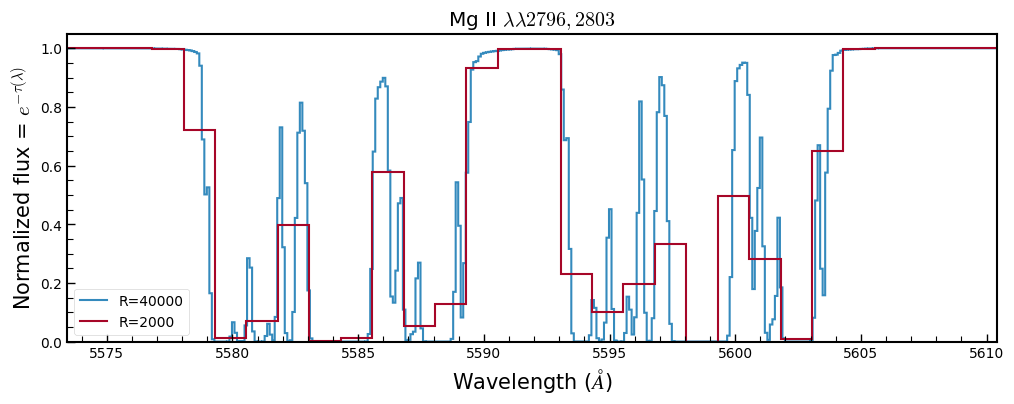

In [70]:
# Let's have a look at Mg II at different spectral resolutions!
wavelength_edges = np.concatenate((wavelength - 0.01/2, [wavelength[-1] + 0.01/2]))
wavelength_edges_low = np.concatenate((new_wave_low_R - 1.25/2, [new_wave_low_R[-1] + 1.25/2]))
wavelength_edges_high = np.concatenate((new_wave_high_R -0.1/2, [new_wave_high_R[-1] + 0.1/2]))

plt.figure(figsize=(12,4))

plt.stairs(rebin_high_R_spectrum[35000:], edges=wavelength_edges_high[35000:], linewidth=1.5, label='R=40000')
plt.stairs(rebin_low_R_spectrum[2800:], edges=wavelength_edges_low[2800:], linewidth=1.5, label='R=2000')

plt.xlim((1+z) * 2800 - 19, (1+z) * 2800 + 18) 
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)
plt.hlines(0, (1+z) * 2800 - 18, (1+z) * 2800 + 18, linestyle='--', color='black')

plt.legend()
plt.title(r'Mg II $\lambda\lambda 2796,2803$')
plt.show()


In [183]:
# we compute the angular momentum
sp = ds.sphere(center, (0.1 * R_vir.value, 'kpc'))

P_edge_on, N_edge_on, W_edge_on = coords.create_PNW_base(ds, 0, center,0.1 * R_vir.value)        # edge on
P_face_on, N_face_on, W_face_on = coords.create_PNW_base(ds, np.pi/2, center,0.1 * R_vir.value)          # face on

In [213]:
N_rays = 35
delta_center = np.linspace(-50, 0, N_rays)

center_kpc = center * ds.length_unit.in_units('kpc')
center_PNW = coords.sim_to_pnw_coords(center_kpc, P_edge_on, N_edge_on, W_edge_on)

start_positions_PNW  = np.zeros((N_rays, 3)) 
start_positions_PNW[:,0] = -R_vir.value/2 + center_PNW[0]
start_positions_PNW[:,1] = center_PNW[1]
start_positions_PNW[:,2] = delta_center + center_PNW[2]

end_positions_PNW  = np.zeros((N_rays, 3)) 
end_positions_PNW[:,0] = R_vir.value/2 + center_PNW[0]
end_positions_PNW[:,1] = center_PNW[1]
end_positions_PNW[:,2] = delta_center + center_PNW[2]

start_positions_sim_coords = np.zeros((N_rays,3)) * kpc 
end_positions_sim_coords = np.zeros((N_rays,3)) * kpc

# Conversion from PNW to simulation coordinates
for i in range(N_rays):
    start_positions_sim_coords[i,:] = coords.pnw_to_sim_coords(start_positions_PNW[i,:], P_edge_on, N_edge_on, W_edge_on) 

for i in range(N_rays):
    end_positions_sim_coords[i,:] = coords.pnw_to_sim_coords(end_positions_PNW[i,:], P_edge_on, N_edge_on, W_edge_on) 


In [184]:
projection_edge_on = yt.OffAxisProjectionPlot(ds, P_edge_on, fields= ('gas', 'Mg_p1_number_density'), center=sp.center,
                                            width=(1.2*R_vir.value, 'kpc'), north_vector=N_edge_on)
projection_face_on = yt.OffAxisProjectionPlot(ds, P_face_on, fields= ('gas', 'Mg_p1_number_density'), center=sp.center,
                                            width=(1.2*R_vir.value, 'kpc'), north_vector=N_face_on)

yt : [INFO     ] 2025-06-23 19:36:29,590 xlim = -140.651940 140.651940
yt : [INFO     ] 2025-06-23 19:36:29,593 ylim = -140.651940 140.651940
yt : [INFO     ] 2025-06-23 19:36:29,595 zlim = -17500.000000 17500.000000
yt : [INFO     ] 2025-06-23 19:36:29,597 Making a fixed resolution buffer of (('gas', 'Mg_p1_number_density')) 800 by 800
yt : [WARNING  ] 2025-06-23 19:36:56,061 Plotting ('gas', 'Mg_p1_number_density'): Both positive and negative values. Min = 0.0 cm**(-2), Max = 4.926394772770468e+17 cm**(-2).
yt : [WARNING  ] 2025-06-23 19:36:56,063 Switching to symlog colorbar scaling.
yt : [INFO     ] 2025-06-23 19:36:56,488 xlim = -140.651940 140.651940
yt : [INFO     ] 2025-06-23 19:36:56,492 ylim = -140.651940 140.651940
yt : [INFO     ] 2025-06-23 19:36:56,498 zlim = -17500.000000 17500.000000
yt : [INFO     ] 2025-06-23 19:36:56,506 Making a fixed resolution buffer of (('gas', 'Mg_p1_number_density')) 800 by 800
yt : [WARNING  ] 2025-06-23 19:37:23,642 Plotting ('gas', 'Mg_p1_nu

In [11]:
%%bash
mkdir rays
mkdir spectra

In [214]:
# Creating rays
rays = []
for i in range(N_rays):
    print(f'Doing ray {i+1} out of {N_rays}.')
    ray = trident.make_simple_ray(ds,
                              start_position=[start_positions_sim_coords[i,:][j].value * kpc for j in range(3)],
                              end_position=[end_positions_sim_coords[i,:][j].value * kpc for j in range(3)],
                              data_filename=f"rays/ray_{i}.h5",
                              lines=['Mg II 2796', 'C IV 1548'], line_database='lines2.txt')
    rays.append(ray)

yt : [INFO     ] 2025-06-23 20:01:28,662 Getting segment at z = 0.9972942257819404: [0.7648042  0.08905329 0.19355008] unitary to [0.76950898 0.0938203  0.19355008] unitary.
C:\ProgramData\Anaconda3\lib\site-packages\unyt\array.py:1906: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
yt : [INFO     ] 2025-06-23 20:01:28,666 Getting subsegment: [0.7648042  0.08905329 0.19355008] unitary to [0.76950898 0.0938203  0.19355008] unitary.


Doing ray 1 out of 31.


yt : [INFO     ] 2025-06-23 20:01:37,938 Saving field data to yt dataset: rays/ray_0.h5.
yt : [INFO     ] 2025-06-23 20:01:38,018 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-23 20:01:38,025 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-23 20:01:38,032 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-23 20:01:38,040 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-23 20:01:38,042 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-23 20:01:38,046 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-23 20:01:38,047 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-23 20:01:38,048 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-23 20:01:38,050 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-23 20:01:38,051 Parameters:

Doing ray 2 out of 31.


yt : [INFO     ] 2025-06-23 20:01:45,755 Saving field data to yt dataset: rays/ray_1.h5.
yt : [INFO     ] 2025-06-23 20:01:45,835 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-23 20:01:45,841 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-23 20:01:45,847 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-23 20:01:45,854 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-23 20:01:45,857 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-23 20:01:45,859 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-23 20:01:45,862 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-23 20:01:45,864 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-23 20:01:45,866 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-23 20:01:45,868 Parameters:

...

yt : [INFO     ] 2025-06-23 20:05:13,703 Saving field data to yt dataset: rays/ray_28.h5.
yt : [INFO     ] 2025-06-23 20:05:13,771 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-23 20:05:13,776 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-23 20:05:13,782 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-23 20:05:13,788 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-23 20:05:13,802 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-23 20:05:13,811 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-23 20:05:13,818 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-23 20:05:13,823 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-23 20:05:13,825 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-23 20:05:13,827 Parameters

Doing ray 30 out of 31.


yt : [INFO     ] 2025-06-23 20:05:21,318 Saving field data to yt dataset: rays/ray_29.h5.
yt : [INFO     ] 2025-06-23 20:05:21,386 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-23 20:05:21,393 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-23 20:05:21,399 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-23 20:05:21,405 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-23 20:05:21,408 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-23 20:05:21,409 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-23 20:05:21,411 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-23 20:05:21,413 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-23 20:05:21,415 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-23 20:05:21,417 Parameters

Doing ray 31 out of 31.


yt : [INFO     ] 2025-06-23 20:05:28,912 Saving field data to yt dataset: rays/ray_30.h5.
yt : [INFO     ] 2025-06-23 20:05:28,993 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-23 20:05:28,998 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-23 20:05:29,005 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-23 20:05:29,011 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-23 20:05:29,012 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-23 20:05:29,014 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-23 20:05:29,016 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-23 20:05:29,018 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-23 20:05:29,021 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-23 20:05:29,022 Parameters

In [215]:
for ray in rays[::3]:
    projection_face_on.annotate_ray(ray, arrow=True)


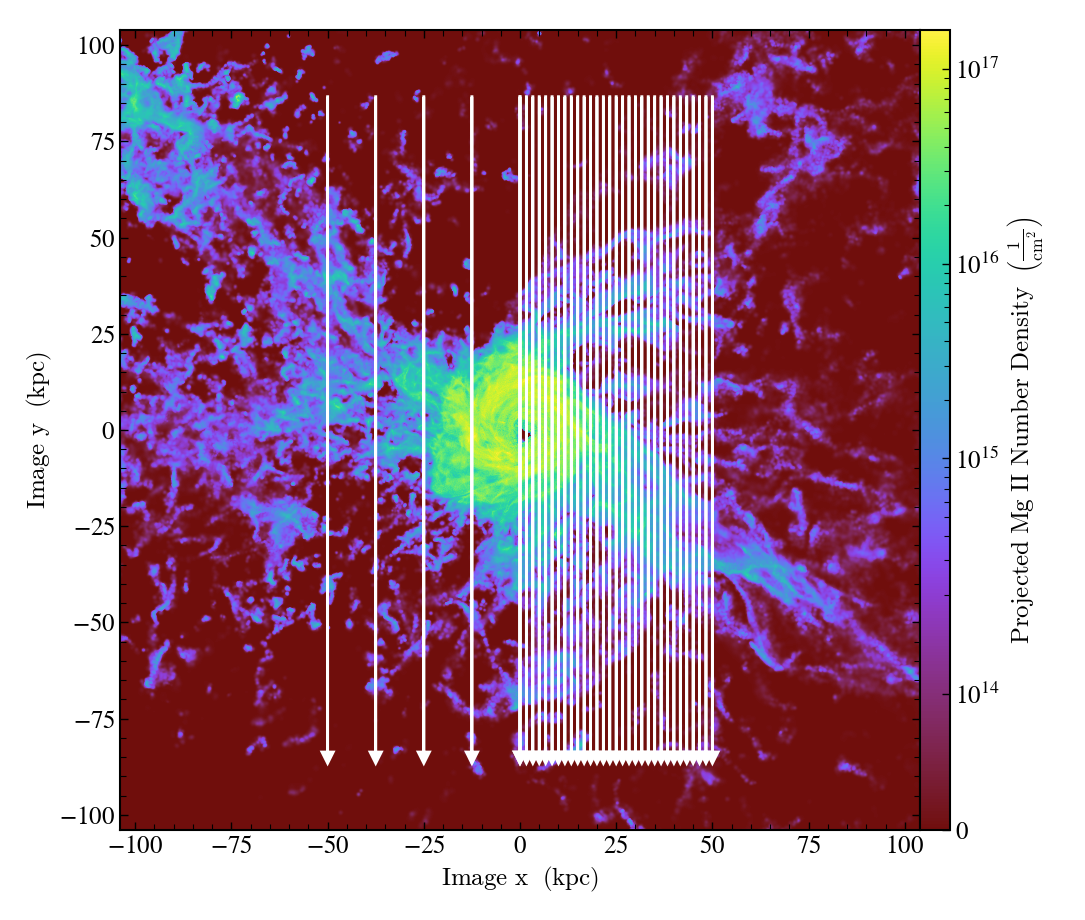

In [216]:
projection_face_on

In [226]:
# Now we generate the spectra
sp_path = 'spectra/'
lines_list = ['Mg II 2796', 'C IV 1548']
z = 1

# We will produce one spectrum for each species, to save some memory.
# We iterate over each species for which we want to generate an spectrum.
for species in lines_list:
    wavelength = int(species.split(' ')[2])    # String are "Element Ionization Lambda"
    path_species = sp_path + species.replace(' ', '_')
    try:
        os.mkdir(path_species)
    except:
        pass
    
    for i in range(N_rays):
        ray_name = f'rays/ray_{i}.h5'
        name_spectrum = path_species + f'/spectrum_{i}.txt'
        min_lambda = (1+z) * wavelength - 25
        max_lambda = (1+z) * wavelength + 25
        sg = trident.SpectrumGenerator(lambda_min=min_lambda, lambda_max=max_lambda,
                                                        dlambda=0.01, line_database='lines2.txt')
        sg.make_spectrum(ray_name, lines=lines_list)
        sg.save_spectrum(name_spectrum)

yt : [INFO     ] 2025-06-23 20:07:29,872 Setting instrument to Custom
yt : [INFO     ] 2025-06-23 20:07:29,952 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-23 20:07:29,959 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-23 20:07:29,966 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-23 20:07:29,977 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-23 20:07:29,980 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-23 20:07:29,983 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-23 20:07:29,988 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-23 20:07:29,990 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-23 20:07:29,992 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-23 20:07:29,994 Parameters: hubble_constant   

In [228]:
# We now load all our generated_spectra for MgII and CIV and compute basic things like EW and a line centriod

mg_ii_spectra = np.array([np.loadtxt(f'spectra/Mg_II_2796/spectrum_{i}.txt', usecols=(0,2)) for i in range(N_rays)])
c_iv_spectra = np.array([np.loadtxt(f'spectra/C_IV_1548/spectrum_{i}.txt', usecols=(0,2)) for i in range(N_rays)])

delta_wave = 0.01 # angstrom
z = ds.current_redshift
mg_ii_spectra.shape

ew_mgii = np.trapz( (1-mg_ii_spectra[:,:,1]), axis=1, dx=delta_wave) / (1 + z)  # divide by (1+z) to make it rest frame :)
ew_civ = np.trapz( (1-c_iv_spectra[:,:,1]), axis=1, dx=delta_wave) / (1 + z)  # divide by (1+z) to make it rest frame :)


We will also compute the line centroids, defined as

$$<\lambda> = \frac{\int (1 - f_{norm}(\lambda)) \lambda d \lambda}{\int (1 - f_{norm}(\lambda)) d \lambda} $$

In [229]:
centroid_mgii = np.sum( (1-mg_ii_spectra[:,:,1]) * mg_ii_spectra[:,:,0], axis=1) / np.sum((1-mg_ii_spectra[:,:,1]), axis=1)  
centroid_civ = np.sum( (1-c_iv_spectra[:,:,1]) * c_iv_spectra[:,:,0], axis=1) / np.sum((1-c_iv_spectra[:,:,1]), axis=1)  

In [230]:
# To velocity conversion
from scipy.constants import c 
mgii_lambda0 = 2796.352
civ_lambda0 = 1548.187

vel_mgii = (c/1000) * (centroid_mgii - (1+z) * mgii_lambda0) / ((1+z) * mgii_lambda0)
vel_civ = (c/1000) * (centroid_civ - (1+z) * civ_lambda0) / ((1+z) * civ_lambda0)

In [274]:
systemic_vel = (velocity_gal * P_edge_on).sum().value

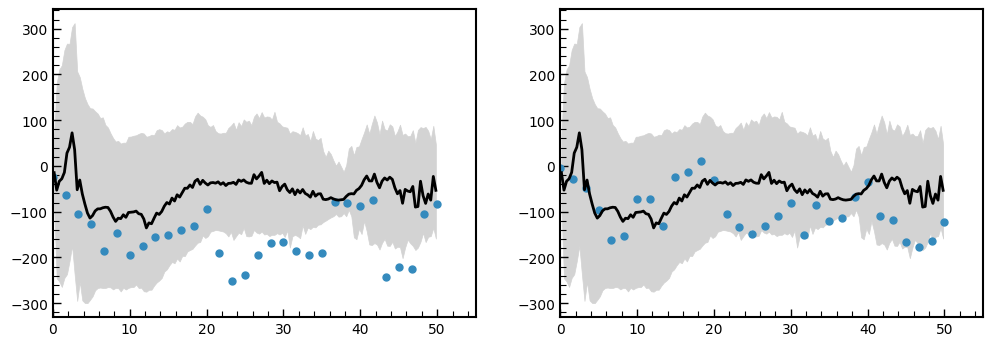

In [277]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(-delta_center, -(vel_mgii - (-1.) * systemic_vel), 'o', markersize=5)
plt.xlim(0,55)

plt.subplot(122)
plt.plot(-delta_center, -(vel_civ - (-1) * systemic_vel), 'o', markersize=5)
plt.xlim(0,55)